In [108]:
import sys
import numpy as np
import pandas as pd
sys.path.append("..")

from core.helpers.df_gen import make_sample_df

df = make_sample_df()
target_column = "churned"


print(df.shape)
df.head()

(1000, 9)


,age,annual_income,account_balance,tenure_months,num_products,country,plan_type,is_active,churned
0,23,83664.29,1987.47,119,3,UK,standard,True,0
1,65,56830.40,1210.05,3,4,JP,standard,True,0
2,58,66615.54,6135.23,28,1,DE,basic,True,0
3,45,53864.34,3793.75,31,1,UK,standard,True,0
4,44,51591.85,1316.98,30,5,DE,premium,False,0


In [109]:
df.describe()

,age,annual_income,account_balance,tenure_months,num_products,churned
count,1000.000000,955.000000,920.000000,1000.00000,1000.000000,1000.000000
mean,48.680000,54494.944545,3041.148043,59.29300,2.895000,0.097000
std,17.907325,20539.326672,3275.761637,33.65525,1.438069,0.296106
min,18.000000,-17968.260000,4.140000,0.00000,1.000000,0.000000
25%,33.000000,41257.750000,853.062500,29.75000,2.000000,0.000000
50%,49.000000,55026.800000,1991.320000,60.00000,3.000000,0.000000
75%,65.000000,67743.775000,3940.745000,89.00000,4.000000,0.000000
max,79.000000,118577.070000,28554.360000,119.00000,5.000000,1.000000


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FunctionTransformer, Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Sum missing")
print(df.isna().sum())

print("\nAll missing")
print(df.isna().sum().sum())

print("\nAverage missing")
print(df.isna().mean())

X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object", "string", "str", "category", "bool"]
).columns.tolist()


numeric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("to_object", FunctionTransformer(lambda X: X.astype(object), feature_names_out="one-to-one")),
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
], remainder="drop")

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

Sum missing
age                 0
annual_income      45
account_balance    80
tenure_months       0
num_products        0
country            44
plan_type          31
is_active           0
churned             0
dtype: int64

All missing
200

Average missing
age                0.000
annual_income      0.045
account_balance    0.080
tenure_months      0.000
num_products       0.000
country            0.044
plan_type          0.031
is_active          0.000
churned            0.000
dtype: float64


In [111]:
print(f"Missing values in transformed data {np.isnan(X_train_preprocessed).sum() + np.isnan(X_test_preprocessed).sum()}")

Missing values in transformed data 0


In [ ]:
from imblearn.over_sampling import SMOTE

print("Class distribution before SMOTE:")
print(y_train.value_counts())

counts = y_train.value_counts()
if len(counts) > 1 and (counts.min() / counts.max()) < 0.3:
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_preprocessed, y_train)
    print("\nSMOTE applied. New class distribution:")
    print(pd.Series(y_train_resampled).value_counts())
else:
    X_train_resampled, y_train_resampled = X_train_preprocessed, y_train
    print("\nData is sufficiently balanced. SMOTE skipped.")

Class distribution before SMOTE:
churned
0    723
1     77
Name: count, dtype: int64

SMOTE applied. New class distribution:
churned
0    723
1    723
Name: count, dtype: int64


In [ ]:
# from sklearn.decomposition import PCA


# pca = PCA(n_components=0.95)
# X_train_resampled = pca.fit_transform(X_train_resampled)
# # X_test_preprocessed = pca.transform(X_test_preprocessed)

# print(f"Train shape: {X_train_resampled.shape}")
# print(f"Test shape:  {X_test_preprocessed.shape}")
# print(f"Components kept: {pca.n_components_}")

Train shape: (1446, 7)
Test shape:  (200, 10)
Components kept: 7


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

param_grid = {
    "n_estimators":      [200],
    "max_depth":         [None, 10, 20],
    "min_samples_split": [2, 10],
    "min_samples_leaf":  [1, 4],
    "max_features":      ["sqrt"],
}

search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train_resampled, y_train_resampled)

print(f"Best params: {search.best_params_}")
print(f"Best CV f1_weighted: {search.best_score_:.4f}\n")

rf_model = search.best_estimator_
y_pred = rf_model.predict(X_test_preprocessed)
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV f1_weighted: 0.9212



ValueError: X has 10 features, but RandomForestClassifier is expecting 7 features as input.

In [ ]:
from sklearn.svm import SVC
clf_svm = SVC(kernel='rbf', probability=True)
clf_svm.fit(X_train_resampled, y_train_resampled)

y_pred = clf_svm.predict(X_test_preprocessed)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.78      0.84       180
           1       0.11      0.25      0.15        20

    accuracy                           0.72       200
   macro avg       0.51      0.51      0.49       200
weighted avg       0.82      0.72      0.77       200



In [ ]:
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

alphas = np.logspace(-3, 3, 50)   # 0.001 to 1000, 50 values

reg_xgb = RidgeCV(alphas=alphas, scoring="r2")
reg_xgb.fit(X_train_resampled, y_train_resampled)

print(f"Best alpha: {reg_xgb.alpha_}")
print(f"Best CV score (R²): {reg_xgb.best_score_:.4f}")

y_pred = reg_xgb.predict(X_test_preprocessed)


# To be returned
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"\nTest set metrics:")
print(f"  MAE:  {mae:.4f}")
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²:   {r2:.4f}")

Best alpha: 59.636233165946365
Best CV score (R²): 0.0345

Test set metrics:
  MAE:  0.4854
  MSE:  0.2480
  RMSE: 0.4980
  R²:   -1.7551


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Validation set out of the resamples to try the hyper parameters optimization
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_resampled, y_train_resampled, test_size=0.2, random_state=42
)

reg_xgb = XGBRegressor(
    n_estimators=2000,      # celling
    learning_rate=0.05,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
)

reg_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

print(f"Optimal n_estimators: {reg_xgb.best_iteration + 1}")
print(f"Best validation RMSE: {reg_xgb.best_score:.4f}\n")

y_pred = reg_xgb.predict(X_test_preprocessed)


# To be returned
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {mae}")
print(f"MSE:  {mse}")
print(f"RMSE: {rmse}")
print(f"R²:   {r2}")

# MAE: 0.396504670381546, MSE: 0.22571676969528198, R2: -1.5079646110534668 old values before space search

Optimal n_estimators: 1036
Best validation RMSE: 0.2655

MAE:  0.4349
MSE:  0.2525
RMSE: 0.5025
R²:   -1.8055


k=2: silhouette=0.1141
k=3: silhouette=0.1250
k=4: silhouette=0.1122
k=5: silhouette=0.1176
k=6: silhouette=0.1162
k=7: silhouette=0.1102
k=8: silhouette=0.1133
k=9: silhouette=0.1112
k=10: silhouette=0.1069

Best k by silhouette: 3


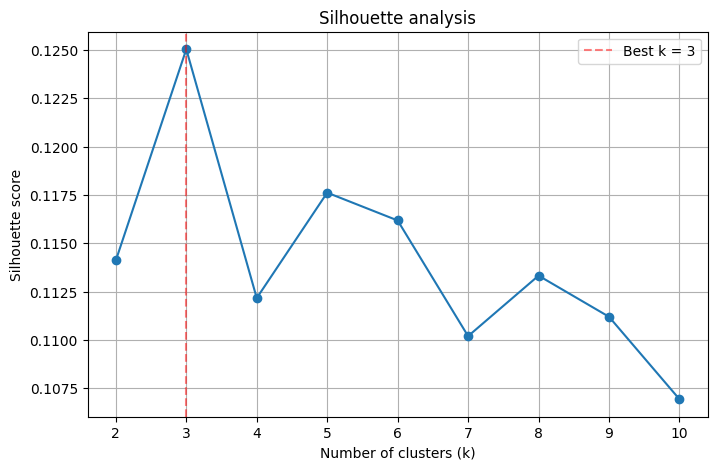

In [103]:
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

k_range = range(2, 11)
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_train_preprocessed)
    score = silhouette_score(X_train_preprocessed, labels)
    silhouettes.append(score)
    print(f"k={k}: silhouette={score:.4f}")

best_k = k_range[np.argmax(silhouettes)]
print(f"\nBest k by silhouette: {best_k}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouettes, "o-")
plt.axvline(best_k, color="red", linestyle="--", alpha=0.5, label=f"Best k = {best_k}")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette analysis")
plt.legend()
plt.grid(True)
plt.show()

In [107]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters_db = dbscan.fit_predict(X_train_preprocessed)

n_clusters = len(set(clusters_db) - {-1})
n_noise = np.sum(clusters_db == -1)

print(f"Clusters found: {n_clusters}")
print(f"Noise points:   {n_noise} ({n_noise / len(clusters_db):.1%})")

if n_clusters < 2:
    print("Silhouette score: undefined (need at least 2 clusters)")
else:
    mask = clusters_db != -1
    score = silhouette_score(X_train_preprocessed[mask], clusters_db[mask])
    print(f"Silhouette Score: {score:.5f}")

Clusters found: 0
Noise points:   800 (100.0%)
Silhouette score: undefined (need at least 2 clusters)
